# Dataset-level over-parameterisation, $P > N$ — R1's crux

> **The criticism.** R1: *"the paper conflates minibatch-level ($P > B$) and dataset-level
> ($P > N$) over-parameterisation \[...\] there is no advantage in the regime the theory
> targets."*  This notebook traces every method across the $P/N = 1$ boundary by
> subsampling the training set, and says plainly whether Sven's advantage is specific to
> $P > N$.

Three scans, one per task, each a `n_data` sweep with the full 13-method baseline suite:

| scan | $P$ | $N$ swept | batching |
|---|---|---|---|
| `rebuttal_overparam_toy_1d_scan` | 593 | 150 … 1200 | **full batch**, 200 epochs |
| `rebuttal_overparam_polynomial_scan` | 673 | 170 … 1350 | **full batch**, 200 epochs |
| `rebuttal_overparam_mnist_scan` | 27,562 | 2,500 … 50,000 | $B = 64$, 20 epochs |

**What makes the arms comparable (C-D3).**  The validation and test splits and the target
scale are now FIXED across `n_data` — only the *training* set is subsampled — so a loss at
$N = 150$ and a loss at $N = 1200$ are the same quantity and may be plotted on one axis.
That was not true of the legacy sweep, which regenerated the target per arm.

**Conventions.**  Selection is the binding rule *inside each arm*: eligible → fewest
diverged → seed-mean final **validation** loss (`analysis_helpers.best_per_method`, the
rule of `CHANGES_NEEDED.md` §1).  Test loss, test accuracy and the full-training-set loss
`train_eval` are OUTCOMES shown beside the selected configuration, never selected on.
Diverged = failed (recorded status, non-finite, or > 10× the pre-training value):
excluded from every mean and counted; every table shows `finished/attempted`.
Error bars are ± 1 std over seeds with the lower edge clipped at the lowest seed.

**Wall clock, honestly.**  These grids ran many processes per GPU and have no standalone
`_timing` pass (only the seven headline scans do), so every second in this notebook is the
scan's own co-tenancy-contaminated clock — an *upper bound*.  The clean budget axes are
epochs, optimizer steps and examples, and the conclusions are drawn on those.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
# This notebook lives in analysis/notebooks/<group>/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import reviewer_figs as rf
from style import (load_results, set_style, DATASET_TITLES, method_color,
                   method_label, seed_spread_label)
from analysis_helpers import add_derived, method_order

set_style()
pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 60)

PLOT_DIR = Path('plots_v2/overparam')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print('plots ->', PLOT_DIR.resolve())
print('seed band =', seed_spread_label(plain=True))

plots -> /n/home/anon/sven-experiments/analysis/plots_v2/overparam
seed band = ± 1 std over seeds


In [2]:
SCANS = {DATASET_TITLES['toy_1d']:         'rebuttal_overparam_toy_1d_scan',
         DATASET_TITLES['polynomial']:     'rebuttal_overparam_polynomial_scan',
         DATASET_TITLES['mnist_labelreg']: 'rebuttal_overparam_mnist_scan'}

data, P = {}, {}
for tag, name in SCANS.items():
    df = add_derived(load_results(name))
    P[tag] = int(df['n_params'].dropna().iloc[0])
    # P/N is NOT put on the run-level frame: it is a deterministic function of n_data,
    # which the selection already groups on, so nothing would be averaged wrongly -- but
    # style.hparam_columns cannot know that and would print the "[style] column 'P_over_N'
    # ... is being AVERAGED OVER" banner from the first arm_table below (ANALYSIS_PLAN
    # section 1's acceptance criterion forbids it).  Every consumer derives it from
    # P[tag] / n_data on the AGGREGATED table instead.
    data[tag] = df

census = pd.DataFrame([rf.scan_census(df, SCANS[tag]) | {'title': tag, 'P': P[tag]}
                       for tag, df in data.items()])
print(census[['title', 'P', 'n_records', 'n_expected', 'n_missing', 'n_diverged',
              'n_failed', 'n_methods', 'seeds']].to_string(index=False))
print()
for tag, df in data.items():
    ns = sorted(df['n_data'].unique())
    print(f'{tag:22s} P={P[tag]:6d}  N = {ns}')
    print(f'{"":22s}        P/N = {[round(P[tag]/n, 2) for n in ns]}')
    print(f'{"":22s}        GPUs: {rf.scan_census(df)["gpus"]}')

Loaded 3240 runs from ../experiment_results/_cache/rebuttal_overparam_toy_1d_scan.slim.pkl (slim cache)


Loaded 4320 runs from ../experiment_results/_cache/rebuttal_overparam_polynomial_scan.slim.pkl (slim cache)


Loaded 3600 runs from ../experiment_results/_cache/rebuttal_overparam_mnist_scan.slim.pkl (slim cache)


             title     P  n_records  n_expected  n_missing  n_diverged  n_failed  n_methods                          seeds
            Toy 1D   593       3240        3240          0         202         0         13 [1000, 1001, 1002, 1003, 1004]
 Random Polynomial   673       4320        4320          0         369         0         13 [2000, 2001, 2002, 2003, 2004]
MNIST (label reg.) 27562       3600        3600          0         649         0         13 [3000, 3001, 3002, 3003, 3004]

Toy 1D                 P=   593  N = [np.int64(150), np.int64(300), np.int64(600), np.int64(1200)]
                              P/N = [np.float64(3.95), np.float64(1.98), np.float64(0.99), np.float64(0.49)]
                              GPUs: {'NVIDIA A100-SXM4-40GB MIG 3g.20gb': 2562, 'NVIDIA A100-SXM4-80GB': 678}
Random Polynomial      P=   673  N = [np.int64(170), np.int64(340), np.int64(675), np.int64(1350)]
                              P/N = [np.float64(3.96), np.float64(1.98), np.float64(1.0), 

## 1. Selection per arm, and the outcomes beside it

One table per task: the configuration each method's **validation** loss selects at each
$N$, with its final validation loss, final **test** loss and the full-training-set loss
`train_eval` (the interpolation check — the running `train` curve is an average over
minibatches visited while the parameters moved, so it is not the loss of the final model).

In [3]:
best, ranks = {}, {}
for tag, df in data.items():
    b = rf.arm_table(df, 'n_data')
    b['P_over_N'] = P[tag] / b['n_data']
    best[tag] = b
    ranks[tag] = rf.rank_table(b, 'n_data')
    ranks[tag]['P_over_N'] = P[tag] / ranks[tag]['n_data']

COLS = ['n_data', 'P_over_N', 'display', 'config', 'counts',
        'final_val_loss', 'final_val_loss_std',
        'final_test_loss', 'final_test_loss_std',
        'final_train_eval', 'final_train_eval_std', 'rank_eff', 'total_time']
for tag, b in best.items():
    print(f'=== {tag}  (P = {P[tag]}) ===   ' + seed_spread_label(plain=True)
          + ' on the _std columns; rank_eff = singular values actually kept (Sven only)')
    t = b.sort_values(['n_data', 'final_val_loss'])[COLS]
    print(t.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    print()

=== Toy 1D  (P = 593) ===   ± 1 std over seeds on the _std columns; rank_eff = singular values actually kept (Sven only)
 n_data  P_over_N           display                    config counts  final_val_loss  final_val_loss_std  final_test_loss  final_test_loss_std  final_train_eval  final_train_eval_std  rank_eff  total_time
    150     3.953 Stochastic L-BFGS         lr=1, mi=3, hs=10    5/5       3.219e-06            1.64e-06        3.323e-06            1.671e-06         2.931e-06             1.504e-06       NaN       32.02
    150     3.953              Sven  lr=0.1, k=37, rtol=0.001    5/5       1.768e-05           1.907e-05         1.75e-05            1.874e-05         1.361e-05             1.315e-05      11.6       32.92
    150     3.953              Adam                    lr=0.1    5/5       0.0001112            7.49e-05        0.0001081            7.097e-05         6.161e-05             3.281e-05       NaN       31.93
    150     3.953             AdamW                    lr=0

### Is the placement bigger than the seeds?

The ranks above are an ordering of seed *means*.  Whether a placement is a result needs the
**paired** difference: the 5 model seeds fix the initialisation and the data order, so the
same seed on both sides removes exactly the variance the error bars show
(`analysis/lib/paired.py`, the campaign's one implementation).  Below, per arm, Sven's rank and
the paired gap to the two configurations nearest to it in the ordering — the ones the rank is
actually decided against.  `mean` is Sven − rival, so negative means Sven is better.

In [4]:
import paired

gaps = {}
for tag, b in best.items():
    g = rf.neighbour_gaps(data[tag], b, 'n_data')
    g['P_over_N'] = [P[tag] / n for n in g['n_data']]
    gaps[tag] = g
    print(f'=== {tag} — Sven vs its nearest rivals, paired by model seed '
          f'({paired.interval_label(0.95)}) ===')
    print(g[['n_data', 'P_over_N', 'rank', 'n_field', 'rival_display', 'rival_rank',
             'ref_value', 'rival_value', 'n', 'mean', 'std', 't', 'significant']]
          .to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    print()

print('summary — arms where Sven ranks 1st or 2nd, and whether the gap to the rival it '
      'beat clears the paired seed noise:')
for tag, g in gaps.items():
    for _, r in g[(g['rank'] <= 2) & (g['rival_rank'] > g['rank'])].iterrows():
        verdict = 'SIGNIFICANT' if r['significant'] else 'within seed noise'
        print(f'  {tag:22s} P/N={r["P_over_N"]:6.2f}  Sven {int(r["rank"])}/'
              f'{int(r["n_field"])} vs {r["rival_display"]:>18s}: '
              f'{r["mean"]:+.3g} (t={r["t"]:+.2f}, n={int(r["n"])})  -> {verdict}')
n_sig = sum(int(g[(g['rank'] <= 2) & (g['rival_rank'] > g['rank'])]['significant'].sum())
            for g in gaps.values())
n_tot = sum(len(g[(g['rank'] <= 2) & (g['rival_rank'] > g['rank'])]) for g in gaps.values())
print(f'  -> {n_sig} of {n_tot} of those gaps are significant at 95%.')

=== Toy 1D — Sven vs its nearest rivals, paired by model seed (95% $t$-interval on the mean) ===
 n_data  P_over_N  rank  n_field     rival_display  rival_rank  ref_value  rival_value  n       mean       std       t  significant
    150     3.953     2       13 Stochastic L-BFGS           1  1.768e-05    3.219e-06  5  1.447e-05 1.849e-05   1.749        False
    150     3.953     2       13              Adam           3  1.768e-05    0.0001112  5 -9.349e-05  7.35e-05  -2.844         True
    300     1.977     4       13             AdamW           3  7.071e-05    3.578e-05  5  3.493e-05 0.0001281  0.6098        False
    300     1.977     4       13              SOAP           5  7.071e-05    0.0002717  5  -0.000201 0.0002755  -1.631        False
    600    0.9883     3       13              Adam           2   9.27e-05    5.657e-05  5  3.613e-05  0.000201   0.402        False
    600    0.9883     3       13             AdamW           4   9.27e-05    0.0001358  5 -4.309e-05 0.0001651 

=== MNIST (label reg.) — Sven vs its nearest rivals, paired by model seed (95% $t$-interval on the mean) ===
 n_data  P_over_N  rank  n_field     rival_display  rival_rank  ref_value  rival_value  n       mean      std       t  significant
   2500     11.02     1       13        Polyak SGD           2     0.1243       0.1246  5 -0.0003348 0.005622 -0.1332        False
   2500     11.02     1       13               SGD           3     0.1243       0.1255  5  -0.001167 0.005895 -0.4425        False
   5000     5.512     1       13               SGD           2    0.09889       0.1006  5  -0.001726  0.00463 -0.8338        False
   5000     5.512     1       13 Stochastic L-BFGS           3    0.09889       0.1021  5  -0.003246 0.007248  -1.002        False
  10000     2.756     1       13               SGD           2    0.08143      0.08304  5  -0.001609 0.003648 -0.9863        False
  10000     2.756     1       13             MuonW           3    0.08143      0.08307  5  -0.001639 0.00

### Final validation and test loss vs $P/N$

Sven in black; the dotted line is $P/N = 1$.  If R1's objection were wrong, Sven's curve
would separate from the pack to the *right* of it.

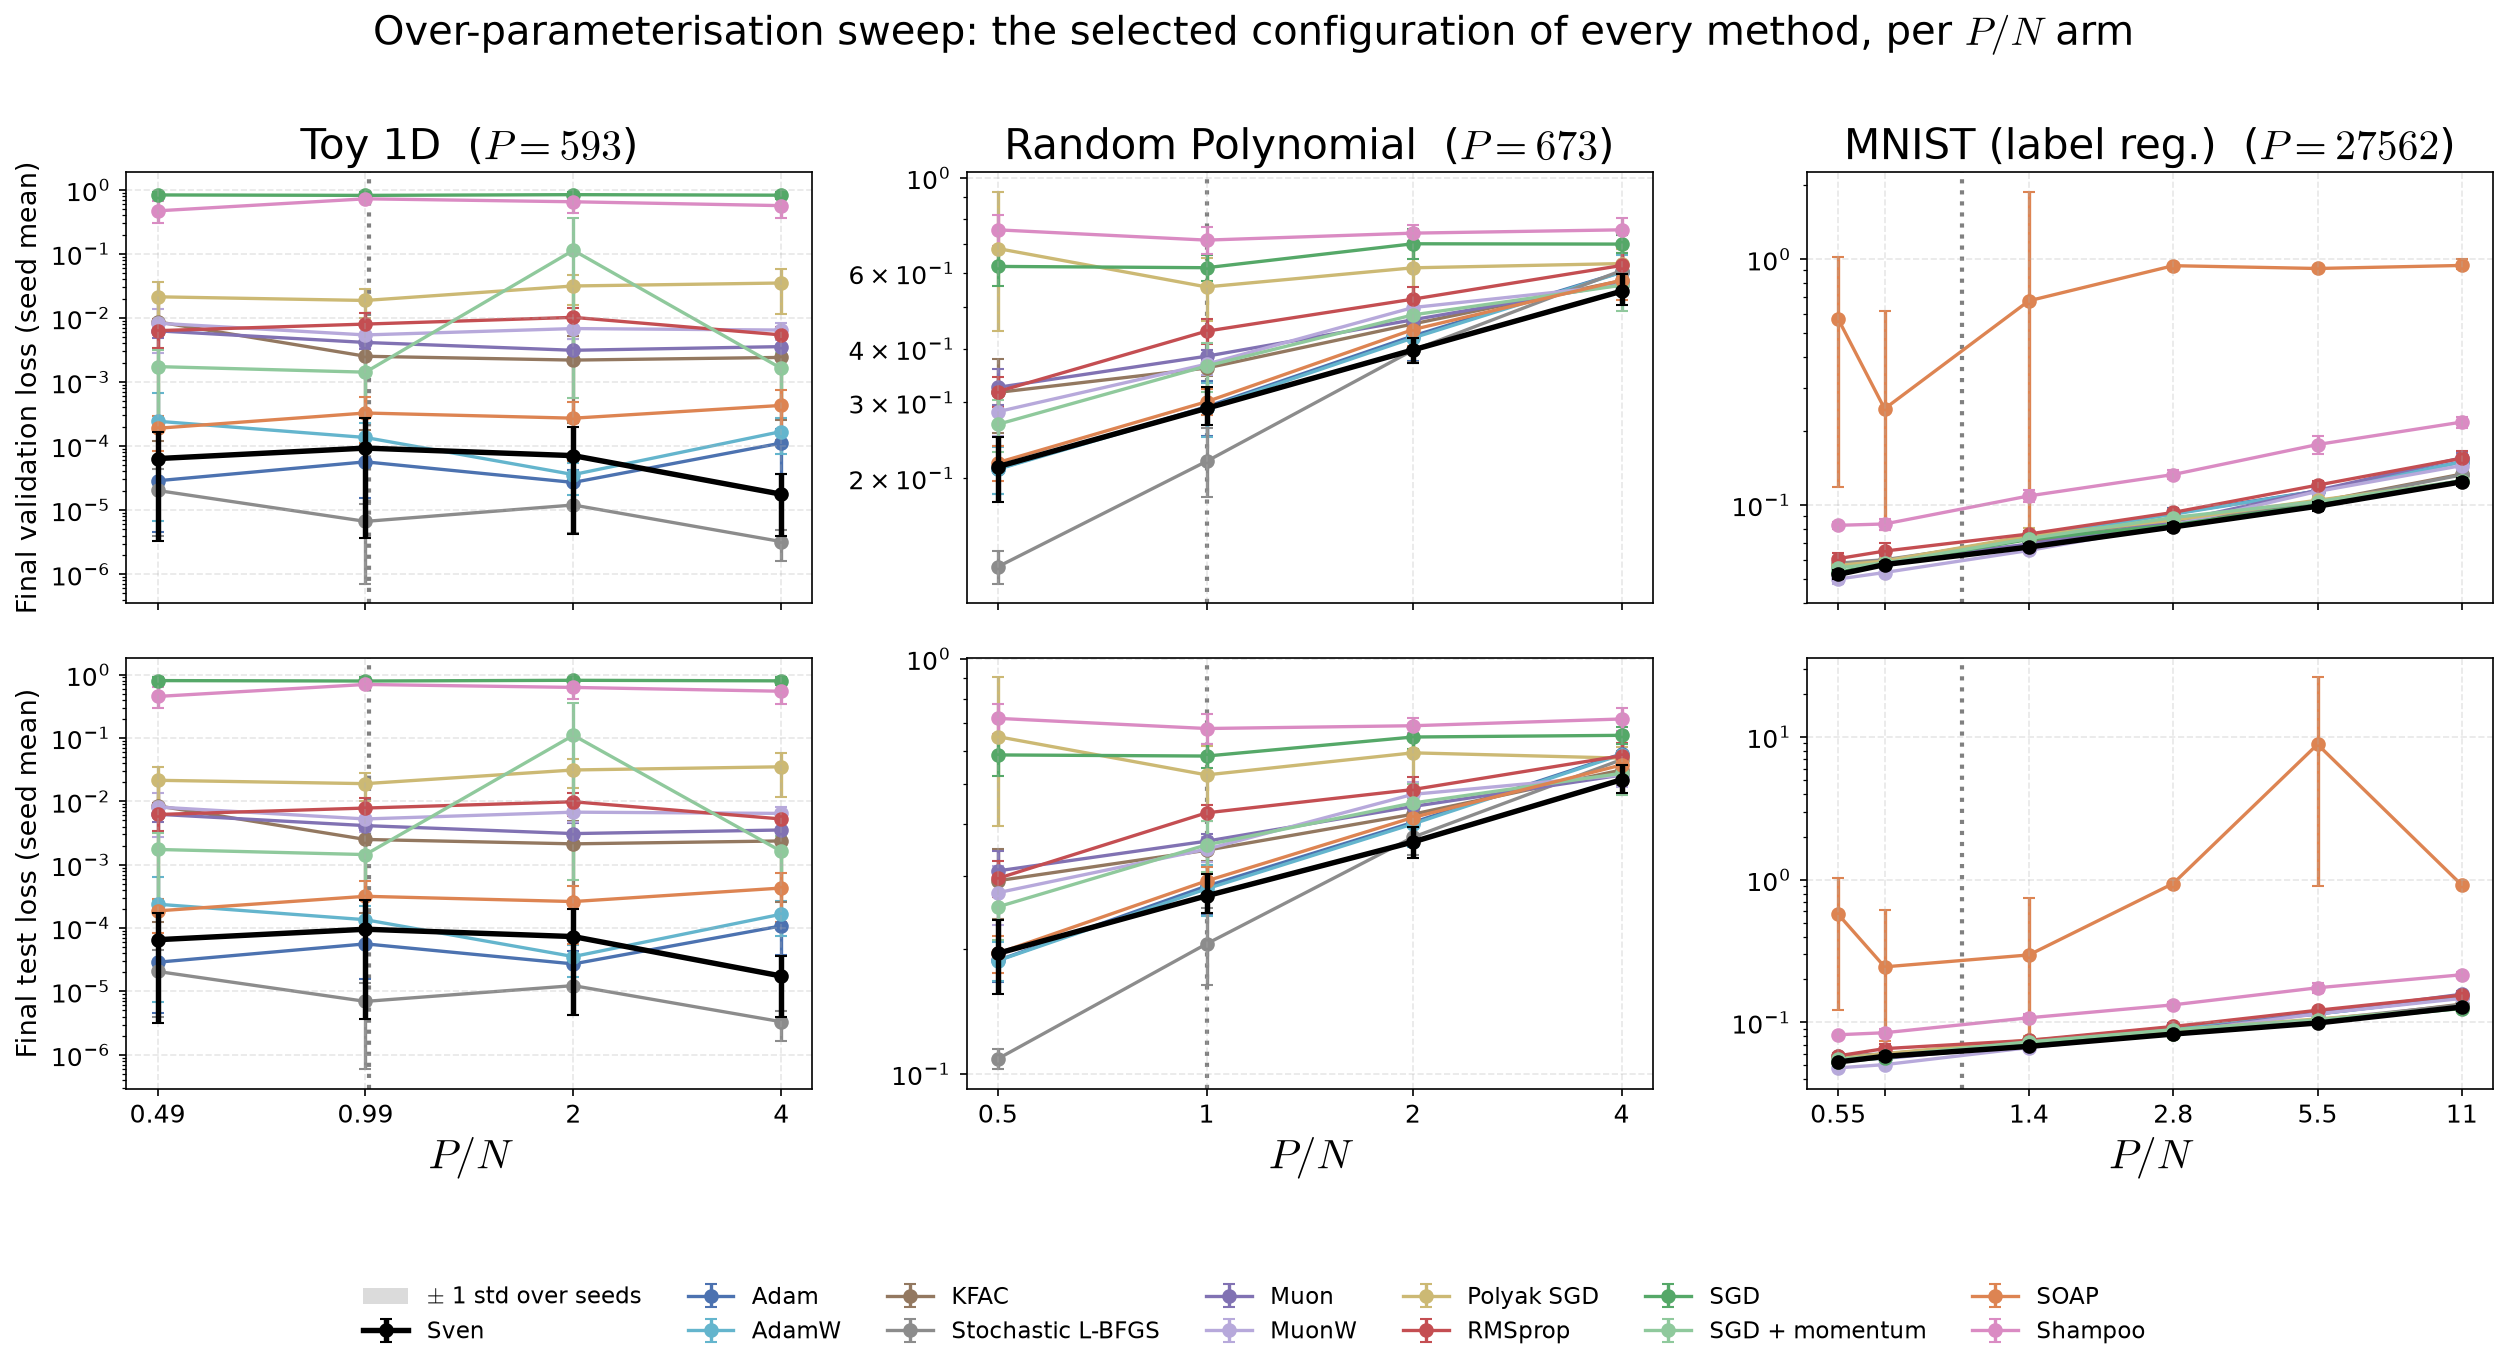

In [5]:
# One short label per ROW (the long ones overlapped each other at axes.labelsize = 20),
# ticks only at the arm values (matplotlib's log minor labels collided inside one
# decade), and the 13-method legend below the figure instead of on top of the data.
ROW_LAB = {'final_val_loss': 'Final validation loss', 'final_test_loss': 'Final test loss'}
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex='col')
for j, (tag, b) in enumerate(best.items()):
    pn = sorted(P[tag] / n for n in b['n_data'].unique())
    for i, q in enumerate(['final_val_loss', 'final_test_loss']):
        ax = axes[i][j]
        rf.plot_arm(ax, b, 'P_over_N', q, logx=True, logy=True)
        ax.axvline(1.0, ls=':', c='gray', zorder=0)
        ax.set_xlabel('$P / N$' if i == 1 else '')
        ax.set_ylabel(f'{ROW_LAB[q]} (seed mean)' if j == 0 else '', fontsize=13)
        rf.arm_ticks(ax, pn, fmt='{:.2g}', min_log_sep=0.12)
        if i == 0:
            ax.set_title(f'{tag}  ($P = {P[tag]}$)')
        ax.grid(alpha=0.3, ls='--')
fig.suptitle('Over-parameterisation sweep: the selected configuration of every method, '
             'per $P/N$ arm', y=1.0)
rf.figure_legend(fig, axes, ncol=7, fontsize=11, bottom=0.11)
rf.savefig(fig, PLOT_DIR, 'loss_vs_PoverN')
plt.show()

### Did they interpolate?  Full-training-set loss vs $P/N$

`train_eval` is the loss of the final model on the whole (subsampled) training set.  On the
two synthetic tasks $P > N$ should be enough to drive it to zero; on MNIST with $P/N = 11$
it is not, which is itself the answer to "is this an interpolating regime".

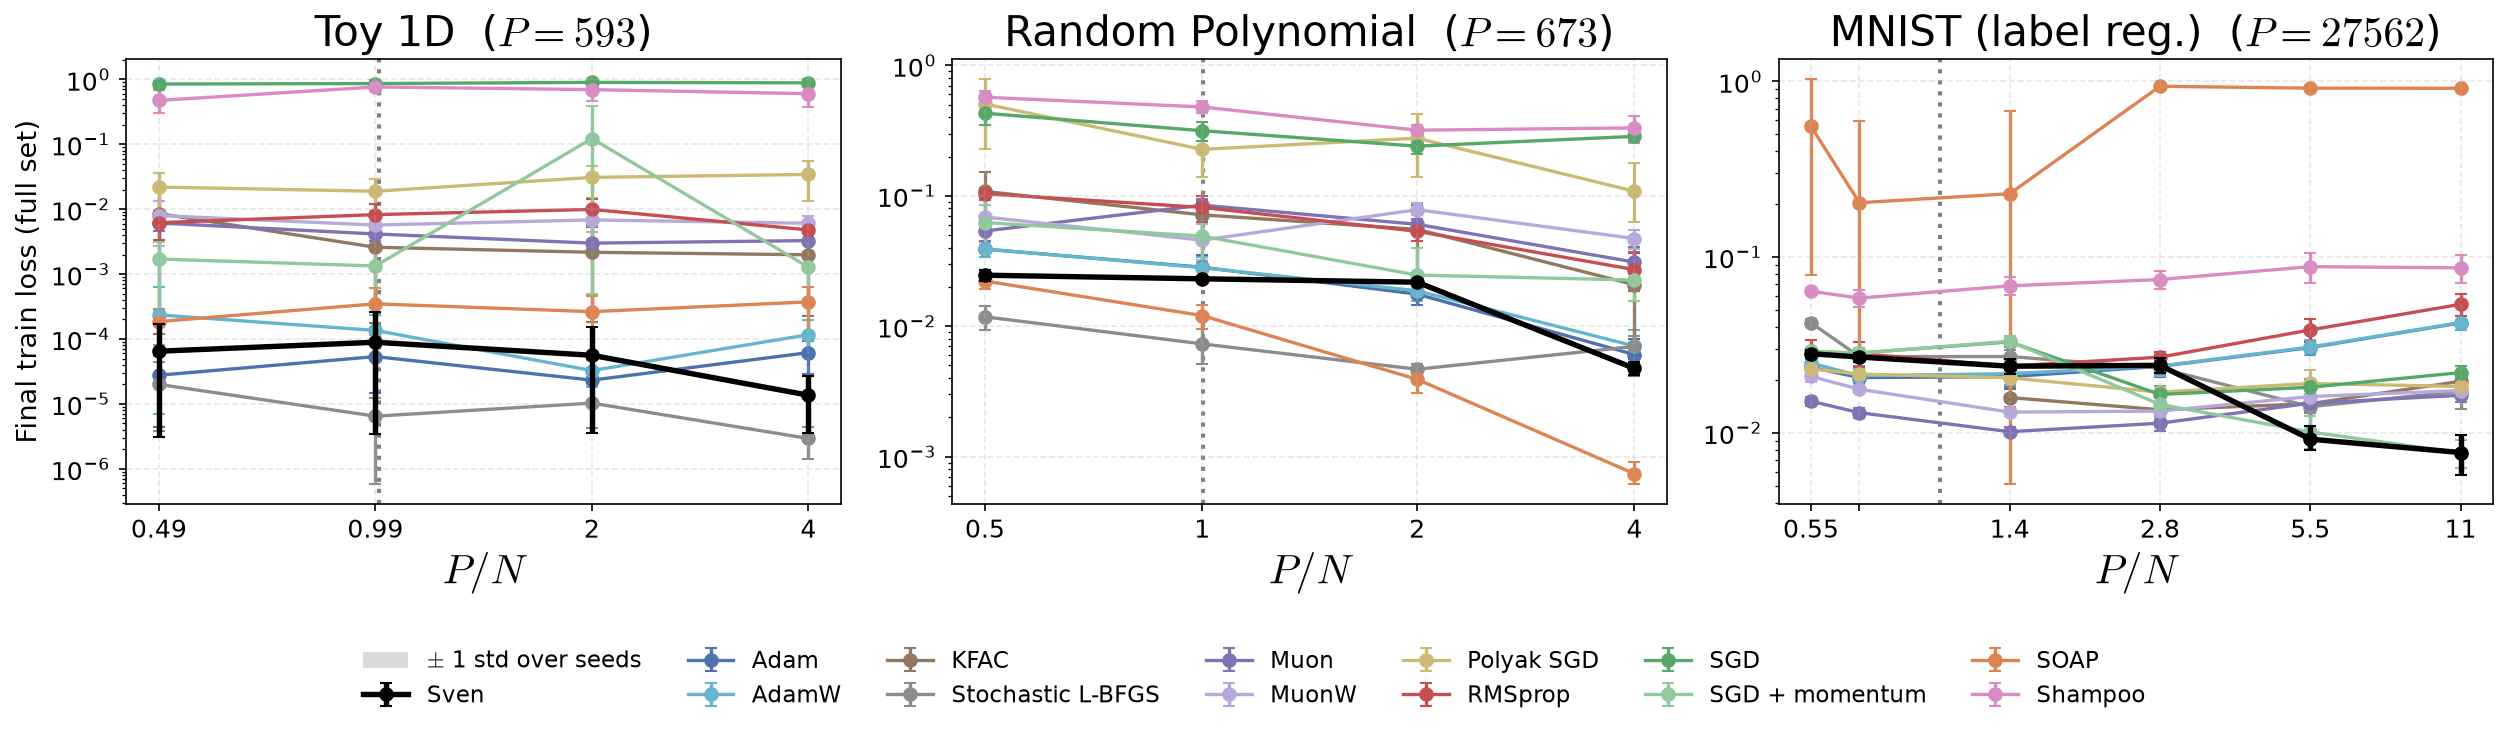

Sven vs the best baseline on the full training set (seed mean):
  Toy 1D                 P/N=  3.95  Sven 1.361e-05   best other:  Stochastic L-BFGS 2.931e-06
  Toy 1D                 P/N=  1.98  Sven 5.610e-05   best other:  Stochastic L-BFGS 1.029e-05
  Toy 1D                 P/N=  0.99  Sven 8.907e-05   best other:  Stochastic L-BFGS 6.462e-06
  Toy 1D                 P/N=  0.49  Sven 6.481e-05   best other:  Stochastic L-BFGS 1.995e-05
  Random Polynomial      P/N=  3.96  Sven 4.744e-03   best other:               SOAP 7.383e-04
  Random Polynomial      P/N=  1.98  Sven 2.175e-02   best other:               SOAP 3.909e-03
  Random Polynomial      P/N=  1.00  Sven 2.308e-02   best other:  Stochastic L-BFGS 7.313e-03
  Random Polynomial      P/N=  0.50  Sven 2.460e-02   best other:  Stochastic L-BFGS 1.180e-02
  MNIST (label reg.)     P/N= 11.02  Sven 7.702e-03   best other:     SGD + momentum 7.681e-03
  MNIST (label reg.)     P/N=  5.51  Sven 9.184e-03   best other:     SGD + momen

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.0))
for j, (ax, (tag, b)) in enumerate(zip(axes, best.items())):
    rf.plot_arm(ax, b, 'P_over_N', 'final_train_eval', logx=True, logy=True)
    ax.axvline(1.0, ls=':', c='gray', zorder=0)
    ax.set_xlabel('$P / N$')
    ax.set_ylabel('Final train loss (full set)' if j == 0 else '', fontsize=13)
    rf.arm_ticks(ax, sorted(P[tag] / n for n in b['n_data'].unique()), fmt='{:.2g}',
                 min_log_sep=0.12)
    ax.set_title(f'{tag}  ($P = {P[tag]}$)')
    ax.grid(alpha=0.3, ls='--')
rf.figure_legend(fig, axes, ncol=7, fontsize=11, bottom=0.13)
rf.savefig(fig, PLOT_DIR, 'trainloss_vs_PoverN')
plt.show()

print('Sven vs the best baseline on the full training set (seed mean):')
for tag, b in best.items():
    for nd in sorted(b['n_data'].unique()):
        s = b[b['n_data'] == nd]
        sv = s[s['method'] == 'Sven']
        other = s[s['method'] != 'Sven'].sort_values('final_train_eval')
        if sv.empty or other.empty:
            continue
        print(f'  {tag:22s} P/N={P[tag]/nd:6.2f}  Sven {sv["final_train_eval"].iloc[0]:.3e}'
              f'   best other: {other["display"].iloc[0]:>18s} '
              f'{other["final_train_eval"].iloc[0]:.3e}')

## 2. Sven's rank across the crossover

The rank is over the methods that have an **eligible** configuration in that arm, so
`n_methods` moves when a baseline has none (K-FAC loses MNIST's two largest $N$ outright —
`torch.linalg.eigh` fails to converge on the rank-deficient Kronecker Fisher).

Sven's rank per arm (1 = best).  rank_val is the selection metric; the other two are outcomes.


              task     P  n_data  P_over_N  rank_val  rank_test  rank_train  n_methods counts  sven_val            winner
            Toy 1D   593     150     3.953         2          2           2         13    5/5 1.768e-05 Stochastic L-BFGS
            Toy 1D   593     300     1.977         4          4           4         13    5/5 7.071e-05 Stochastic L-BFGS
            Toy 1D   593     600    0.9883         3          3           3         13    5/5  9.27e-05 Stochastic L-BFGS
            Toy 1D   593    1200    0.4942         3          3           3         13    5/5  6.36e-05 Stochastic L-BFGS
 Random Polynomial   673     170     3.959         1          1           2         13    5/5    0.5444              Sven
 Random Polynomial   673     340     1.979         2          1           5         13    5/5    0.3975 Stochastic L-BFGS
 Random Polynomial   673     675     0.997         2          2           3         13    5/5    0.2907 Stochastic L-BFGS
 Random Polynomial   673

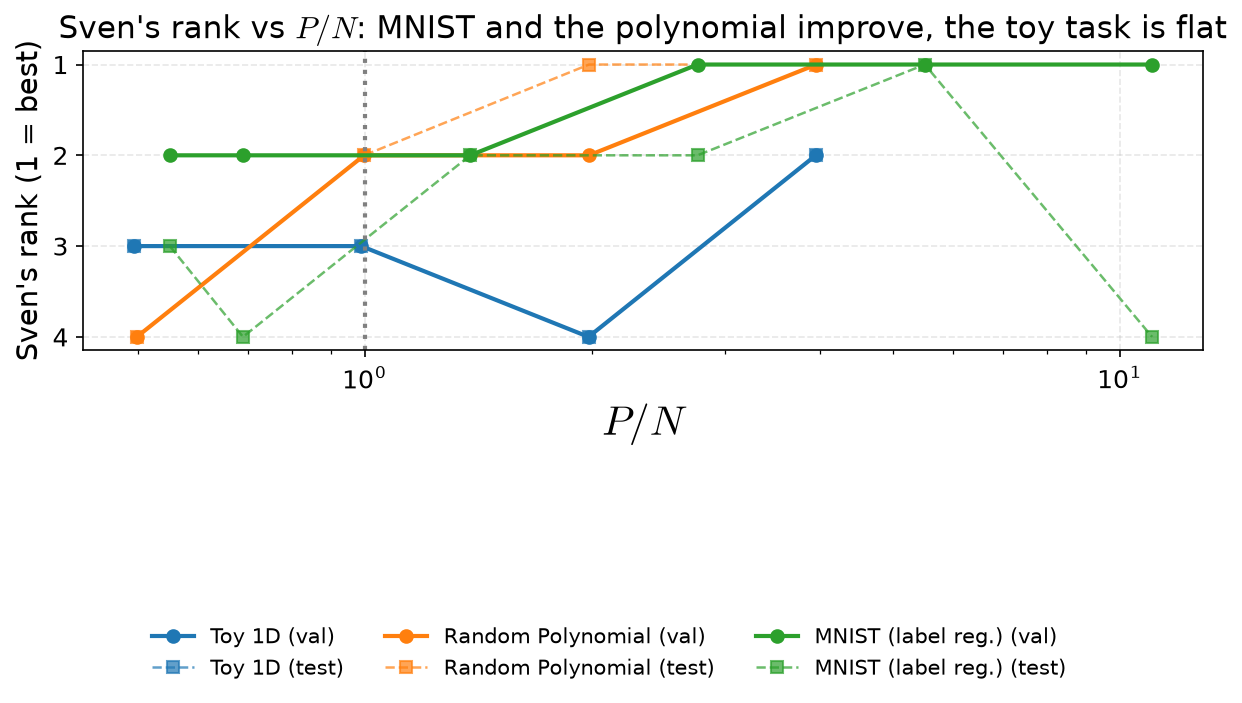

In [7]:
rank_rows = []
for tag, b in best.items():
    r_val = rf.rank_table(b, 'n_data', 'final_val_loss')
    r_test = rf.rank_table(b, 'n_data', 'final_test_loss')
    r_tr = rf.rank_table(b, 'n_data', 'final_train_eval')
    for _, r in r_val[r_val['method'] == 'Sven'].iterrows():
        nd = r['n_data']
        pick = lambda t: t[(t['method'] == 'Sven') & (t['n_data'] == nd)]
        rank_rows.append({
            'task': tag, 'P': P[tag], 'n_data': int(nd), 'P_over_N': P[tag] / nd,
            'rank_val': int(r['rank']), 'rank_test': int(pick(r_test)['rank'].iloc[0]),
            'rank_train': int(pick(r_tr)['rank'].iloc[0]),
            'n_methods': int(r['n_methods']), 'counts': r['counts'],
            'sven_val': r['value'],
            'winner': b[b['n_data'] == nd].sort_values('final_val_loss')['display'].iloc[0]})
sven_rank = pd.DataFrame(rank_rows)
print('Sven\'s rank per arm (1 = best).  rank_val is the selection metric; the other two '
      'are outcomes.')
print(sven_rank.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

print()
print('pooled mean rank over / under P/N = 1, on the selection metric and on the '
      'test outcome:')
for col, name in (('rank_val', 'validation (selected on)'),
                  ('rank_test', 'TEST (outcome)'),
                  ('rank_train', 'train_eval (outcome)')):
    o = sven_rank[sven_rank['P_over_N'] > 1][col].mean()
    u = sven_rank[sven_rank['P_over_N'] < 1][col].mean()
    print(f'  {name:26s}: P/N>1 -> {o:.2f},  P/N<1 -> {u:.2f}   (gap {u - o:+.2f})')
    for tag, sub in sven_rank.groupby('task', sort=False):
        s = sub.sort_values('P_over_N', ascending=False)
        print(f'      {tag:22s} ' + ', '.join(f'{int(v)}' for v in s[col])
              + f'   at P/N = ' + ', '.join(f'{v:.2f}' for v in s['P_over_N']))

# The title states only what all three curves support: the toy line is flat, and a saved
# figure travels without the conclusion that says so.
fig, ax = plt.subplots(figsize=(8.4, 4.8))
for tag, sub in sven_rank.groupby('task', sort=False):
    sub = sub.sort_values('P_over_N')
    ax.plot(sub['P_over_N'], sub['rank_val'], marker='o', lw=2, label=f'{tag} (val)')
    ax.plot(sub['P_over_N'], sub['rank_test'], marker='s', ls='--', lw=1.2, alpha=0.7,
            color=ax.lines[-1].get_color(), label=f'{tag} (test)')
ax.axvline(1.0, ls=':', c='gray')
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_yticks(range(1, int(max(sven_rank['rank_val'].max(),
                               sven_rank['rank_test'].max())) + 1))
ax.set_xlabel('$P / N$')
ax.set_ylabel("Sven's rank (1 = best)", fontsize=14)
ax.set_title("Sven's rank vs $P/N$: MNIST and the polynomial improve, the toy task is "
             'flat', fontsize=15)
ax.grid(alpha=0.3, ls='--')
rf.figure_legend(fig, [ax], ncol=3, fontsize=10, bottom=0.30)
rf.savefig(fig, PLOT_DIR, 'sven_rank_vs_PoverN')
plt.show()

## 3. Robustness: who blows up, and where

The **wide** divergence rule (recorded `status`, non-finite, or a finite blow-up above
10× the pre-training value) over every run of the arm — not just the winner's seeds.  For
Sven the wide rule is the only one that sees anything: `status: diverged` is 0 for Sven on
all three scans, yet it diverges on 111 / 720 (toy), 252 / 1800 (polynomial) and 1 / 360
(MNIST) runs, concentrated at the bottom of each `rtol` grid.

**Two things make a pooled rate misleading, so both are printed.**  (i) The comparison is
per *scan*: pooling the three hides a sign change, and Sven's rate is above SGD's and
SGD+momentum's on one of them.  (ii) The grids are not the same size — Sven's spans an
`rtol` axis the baselines do not have, ~11× as many runs on the two synthetic tasks, and
that axis deliberately includes values known to break (EXPERIMENTS.md §7).  A rate over
1,800 runs two of whose `rtol` values fail about a third of the time is not the same
quantity as a rate over 160.

In [8]:
div = {}
for tag, df in data.items():
    d = rf.divergence_table(df, 'n_data')
    d['task'] = tag
    div[tag] = d

print('Divergence rate per method, PER SCAN (wide rule), worst first, with the size of '
      'the grid each rate is computed over:')
dvr = {}
for tag, df in data.items():
    t = rf.divergence_vs_reference(df, reference='Sven')
    dvr[tag] = t
    print(f'  == {tag} ==   Sven is {t.attrs["reference_rank"]} of {len(t)} worst-first '
          f'at {100 * t.attrs["reference_frac"]:.2f}%')
    print('    ' + t[['display', 'n_diverged', 'n_runs', 'frac',
                      'grid_ratio_vs_reference']]
          .to_string(index=False, float_format=lambda v: f'{v:.4g}')
          .replace('\n', '\n    '))
    print(f'    worse than Sven: {t.attrs["above_reference"]}')
    print(f'    better than Sven: {t.attrs["below_reference"]}')
    print()

print('the comparison the conclusion has to make honestly — Sven against the '
      'first-order methods it is often said to beat on robustness:')
for tag, t in dvr.items():
    sv = float(t.loc[t['method'] == 'Sven', 'frac'].iloc[0])
    bits = []
    for m in ('SGD', 'SGDm', 'RMSprop'):
        r = t[t['method'] == m]
        if r.empty:
            continue
        f = float(r['frac'].iloc[0])
        bits.append(f'{method_label(m)} {100 * f:.2f}% '
                    f'({"WORSE than Sven" if f > sv else "BETTER than Sven"})')
    print(f'  {tag:22s} Sven {100 * sv:.2f}%  vs  ' + ';  '.join(bits))
print()
print('Sven only, per arm — where in the grid does it blow up?')
for tag, df in data.items():
    sv = df[df['method'] == 'Sven']
    if not sv['diverged'].any():
        print(f'  {tag}: 0 diverged of {len(sv)}')
        continue
    t = (sv.groupby(['n_data', 'rtol'])['diverged'].agg(['sum', 'size'])
         .rename(columns={'sum': 'n_diverged', 'size': 'n_runs'}).reset_index())
    t['frac'] = t['n_diverged'] / t['n_runs']
    print(f'  == {tag} ==')
    print('    ' + t.to_string(index=False, float_format=lambda v: f'{v:.3g}')
          .replace('\n', '\n    '))

Divergence rate per method, PER SCAN (wide rule), worst first, with the size of the grid each rate is computed over:
  == Toy 1D ==   Sven is 4 of 13 worst-first at 15.42%
              display  n_diverged  n_runs    frac  grid_ratio_vs_reference
              RMSprop          33     160  0.2062                   0.2222
       SGD + momentum          32     160     0.2                   0.2222
                  SGD          25     160  0.1562                   0.2222
                 Sven         111     720  0.1542                        1
                 Muon           1     160 0.00625                   0.2222
    Stochastic L-BFGS           0     900       0                     1.25
                 KFAC           0     160       0                   0.2222
                AdamW           0     160       0                   0.2222
                 Adam           0     160       0                   0.2222
                MuonW           0     160       0                   0.2222
   

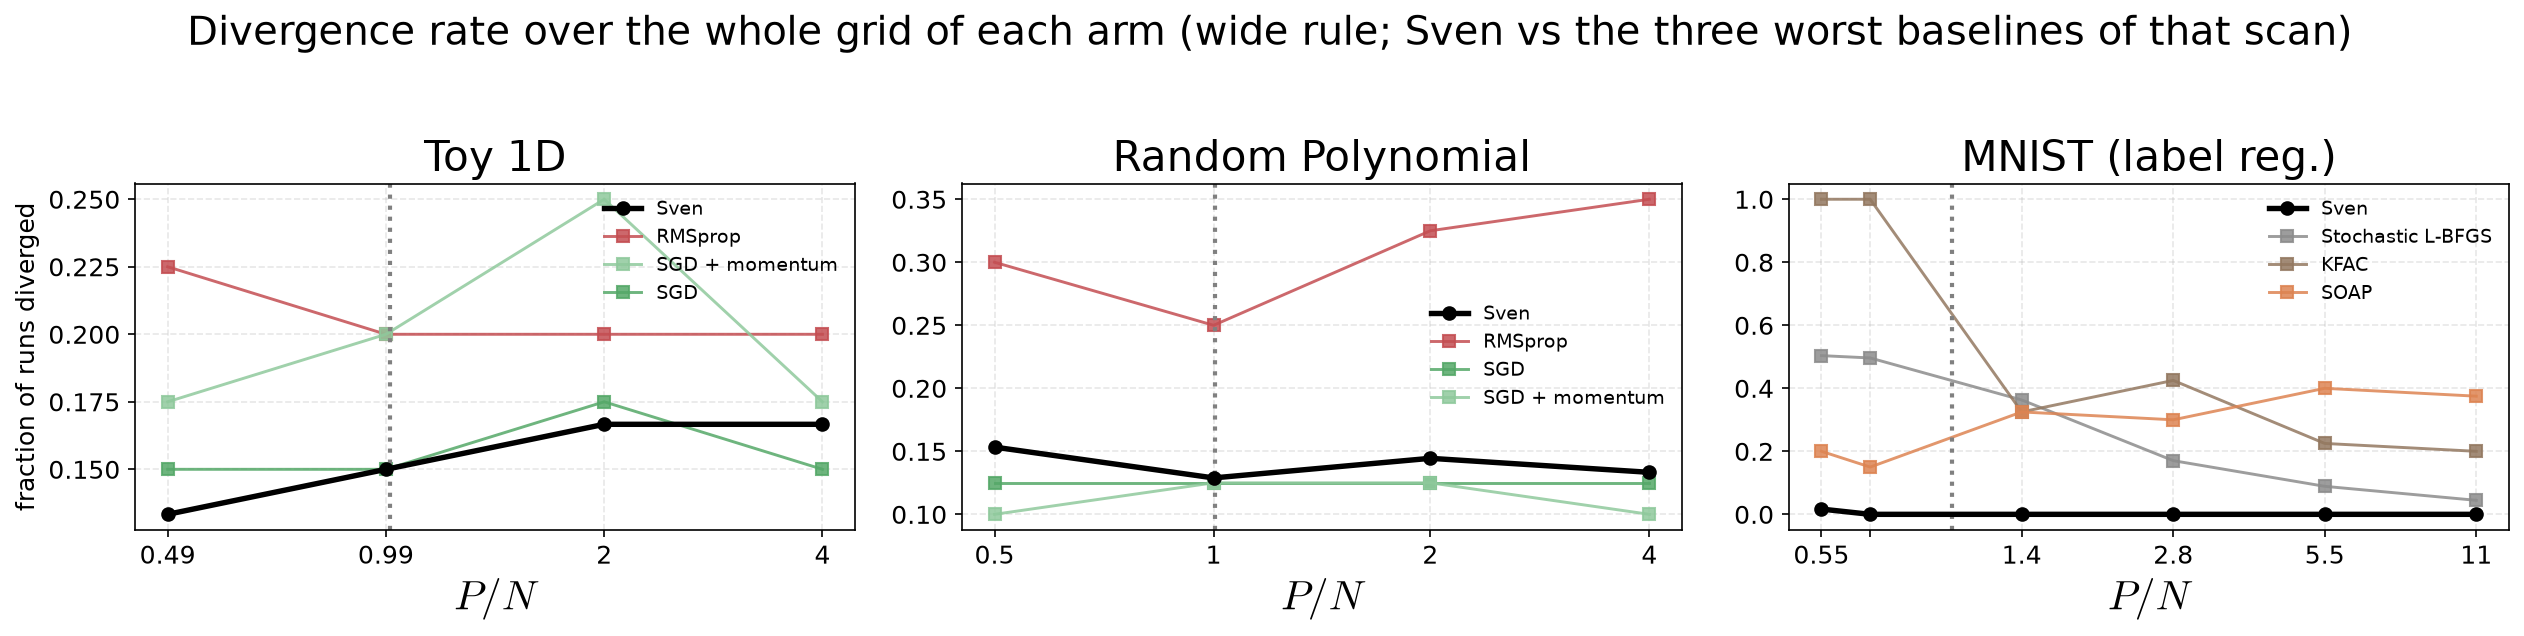

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for ax, (tag, d) in zip(axes, div.items()):
    sub = d[d['method'] == 'Sven'].sort_values('n_data')
    pn = [P[tag] / n for n in sub['n_data']]
    ax.plot(pn, sub['frac'], marker='o', lw=2.6, color='k', label='Sven',
            zorder=3)
    # the three worst BASELINES: Sven is already the black line, and drawing it twice
    # (it is among the worst three on the two synthetic tasks) put it in the legend twice.
    # Colours are the campaign's per-method colours, so a method looks the same in every
    # panel even though each panel shows a different three.
    worst = (d[d['method'] != 'Sven'].groupby('method')['n_diverged'].sum()
             .sort_values(ascending=False).head(3).index)
    for m in worst:
        s = d[d['method'] == m].sort_values('n_data')
        ax.plot([P[tag] / n for n in s['n_data']], s['frac'], marker='s', lw=1.4,
                alpha=0.85, color=method_color(m), label=method_label(m))
    ax.axvline(1.0, ls=':', c='gray')
    ax.set_xscale('log')
    rf.arm_ticks(ax, pn, fmt='{:.2g}', min_log_sep=0.12)
    ax.set_xlabel('$P / N$')
    ax.set_ylabel('fraction of runs diverged' if ax is axes[0] else '', fontsize=12)
    ax.set_title(tag)
    ax.grid(alpha=0.3, ls='--')
    ax.legend(fontsize=9, loc='best')
fig.suptitle('Divergence rate over the whole grid of each arm '
             '(wide rule; Sven vs the three worst baselines of that scan)', y=1.02)
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'divergence_vs_PoverN')
plt.show()

## 4. Time to target

Two target families, both pre-declared before any curve is read:

* the **legacy absolute target**, `train_eval` $< 10^{-3}$ — the threshold the rebuttal's
  "wall-time to train loss < 1e-3" claim used;
* a **per-arm relative target**: the median over methods of that arm's selected
  `train_eval` (resp. validation) loss.  The median and not the best, for the reason
  `headline.target_reference` gives — a target set by the winner is one only the winner
  reaches.  Per arm, because the arms are different problems.

Runs that produce no answer are counted in two separate columns and never added up:
`n_never_reached` (trained to the end, never got there — a statement about the method) and
`n_diverged` (no trajectory to ask — a statement about the run).

In [10]:
reach_abs, reach_rel, targets_rel = {}, {}, {}
for tag, b in best.items():
    reach_abs[tag] = rf.reach_table(data[tag], b, 'n_data', 1e-3, which='train_eval')
    targets_rel[tag] = rf.median_method_target(b, 'final_train_eval', 1.0, arm='n_data')
    reach_rel[tag] = rf.reach_table(data[tag], b, 'n_data', targets_rel[tag],
                                    which='train_eval')

RC = ['n_data', 'display', 'config', 'target', 'n_runs', 'n_reached', 'n_never_reached',
      'n_diverged', 'epochs', 'steps', 'examples', 'sync_s']
for tag in best:
    print(f'=== {tag} — epochs / steps / examples / seconds to train_eval < 1e-3 '
          '(the legacy target) ===')
    t = reach_abs[tag]
    if t['n_reached'].sum() == 0:
        print(f'    NO method reaches 1e-3 in any arm '
              f'({int(t["n_runs"].sum())} runs). The target is not on this task\'s scale.')
    else:
        print(t[t['n_reached'] > 0][RC].to_string(index=False,
                                                  float_format=lambda v: f'{v:.4g}'))
        never = t[t['n_reached'] == 0]
        print(f'    never reached it: {sorted(set(never["display"]))}')
    print()

=== Toy 1D — epochs / steps / examples / seconds to train_eval < 1e-3 (the legacy target) ===
 n_data           display                    config  target  n_runs  n_reached  n_never_reached  n_diverged  epochs  steps  examples  sync_s
    150 Stochastic L-BFGS         lr=1, mi=3, hs=10   0.001       5          5                0           0    28.4   28.4      4260  0.3376
    150             AdamW                    lr=0.1   0.001       5          5                0           0    63.2   63.2      9480  0.1501
    150              Adam                    lr=0.1   0.001       5          5                0           0    64.2   64.2      9630  0.1635
    150              SOAP                    lr=0.1   0.001       5          5                0           0    88.8   88.8 1.332e+04  0.5958
    150              Sven  lr=0.1, k=37, rtol=0.001   0.001       5          5                0           0   107.6  107.6 1.614e+04   1.515
    150              KFAC                  lr=0.001   0.001 

In [11]:
for tag in best:
    print(f'=== {tag} — to the per-arm MEDIAN-method train_eval target ===')
    print('    targets: ' + ', '.join(f'N={k}: {v:.3g}' for k, v in
                                      targets_rel[tag].items()))
    print(reach_rel[tag][RC].to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    print()

=== Toy 1D — to the per-arm MEDIAN-method train_eval target ===
    targets: N=150: 0.00198, N=300: 0.003, N=600: 0.00259, N=1200: 0.00613
 n_data           display                    config   target  n_runs  n_reached  n_never_reached  n_diverged  epochs  steps  examples  sync_s
    150 Stochastic L-BFGS         lr=1, mi=3, hs=10 0.001982       5          5                0           0    25.8   25.8      3870  0.3017
    150              Adam                    lr=0.1 0.001982       5          5                0           0    54.6   54.6      8190  0.1421
    150             AdamW                    lr=0.1 0.001982       5          5                0           0      55     55      8250   0.133
    150              SOAP                    lr=0.1 0.001982       5          5                0           0    74.8   74.8 1.122e+04  0.5382
    150              Sven  lr=0.1, k=37, rtol=0.001 0.001982       5          5                0           0   100.6  100.6 1.509e+04   1.467
    150  

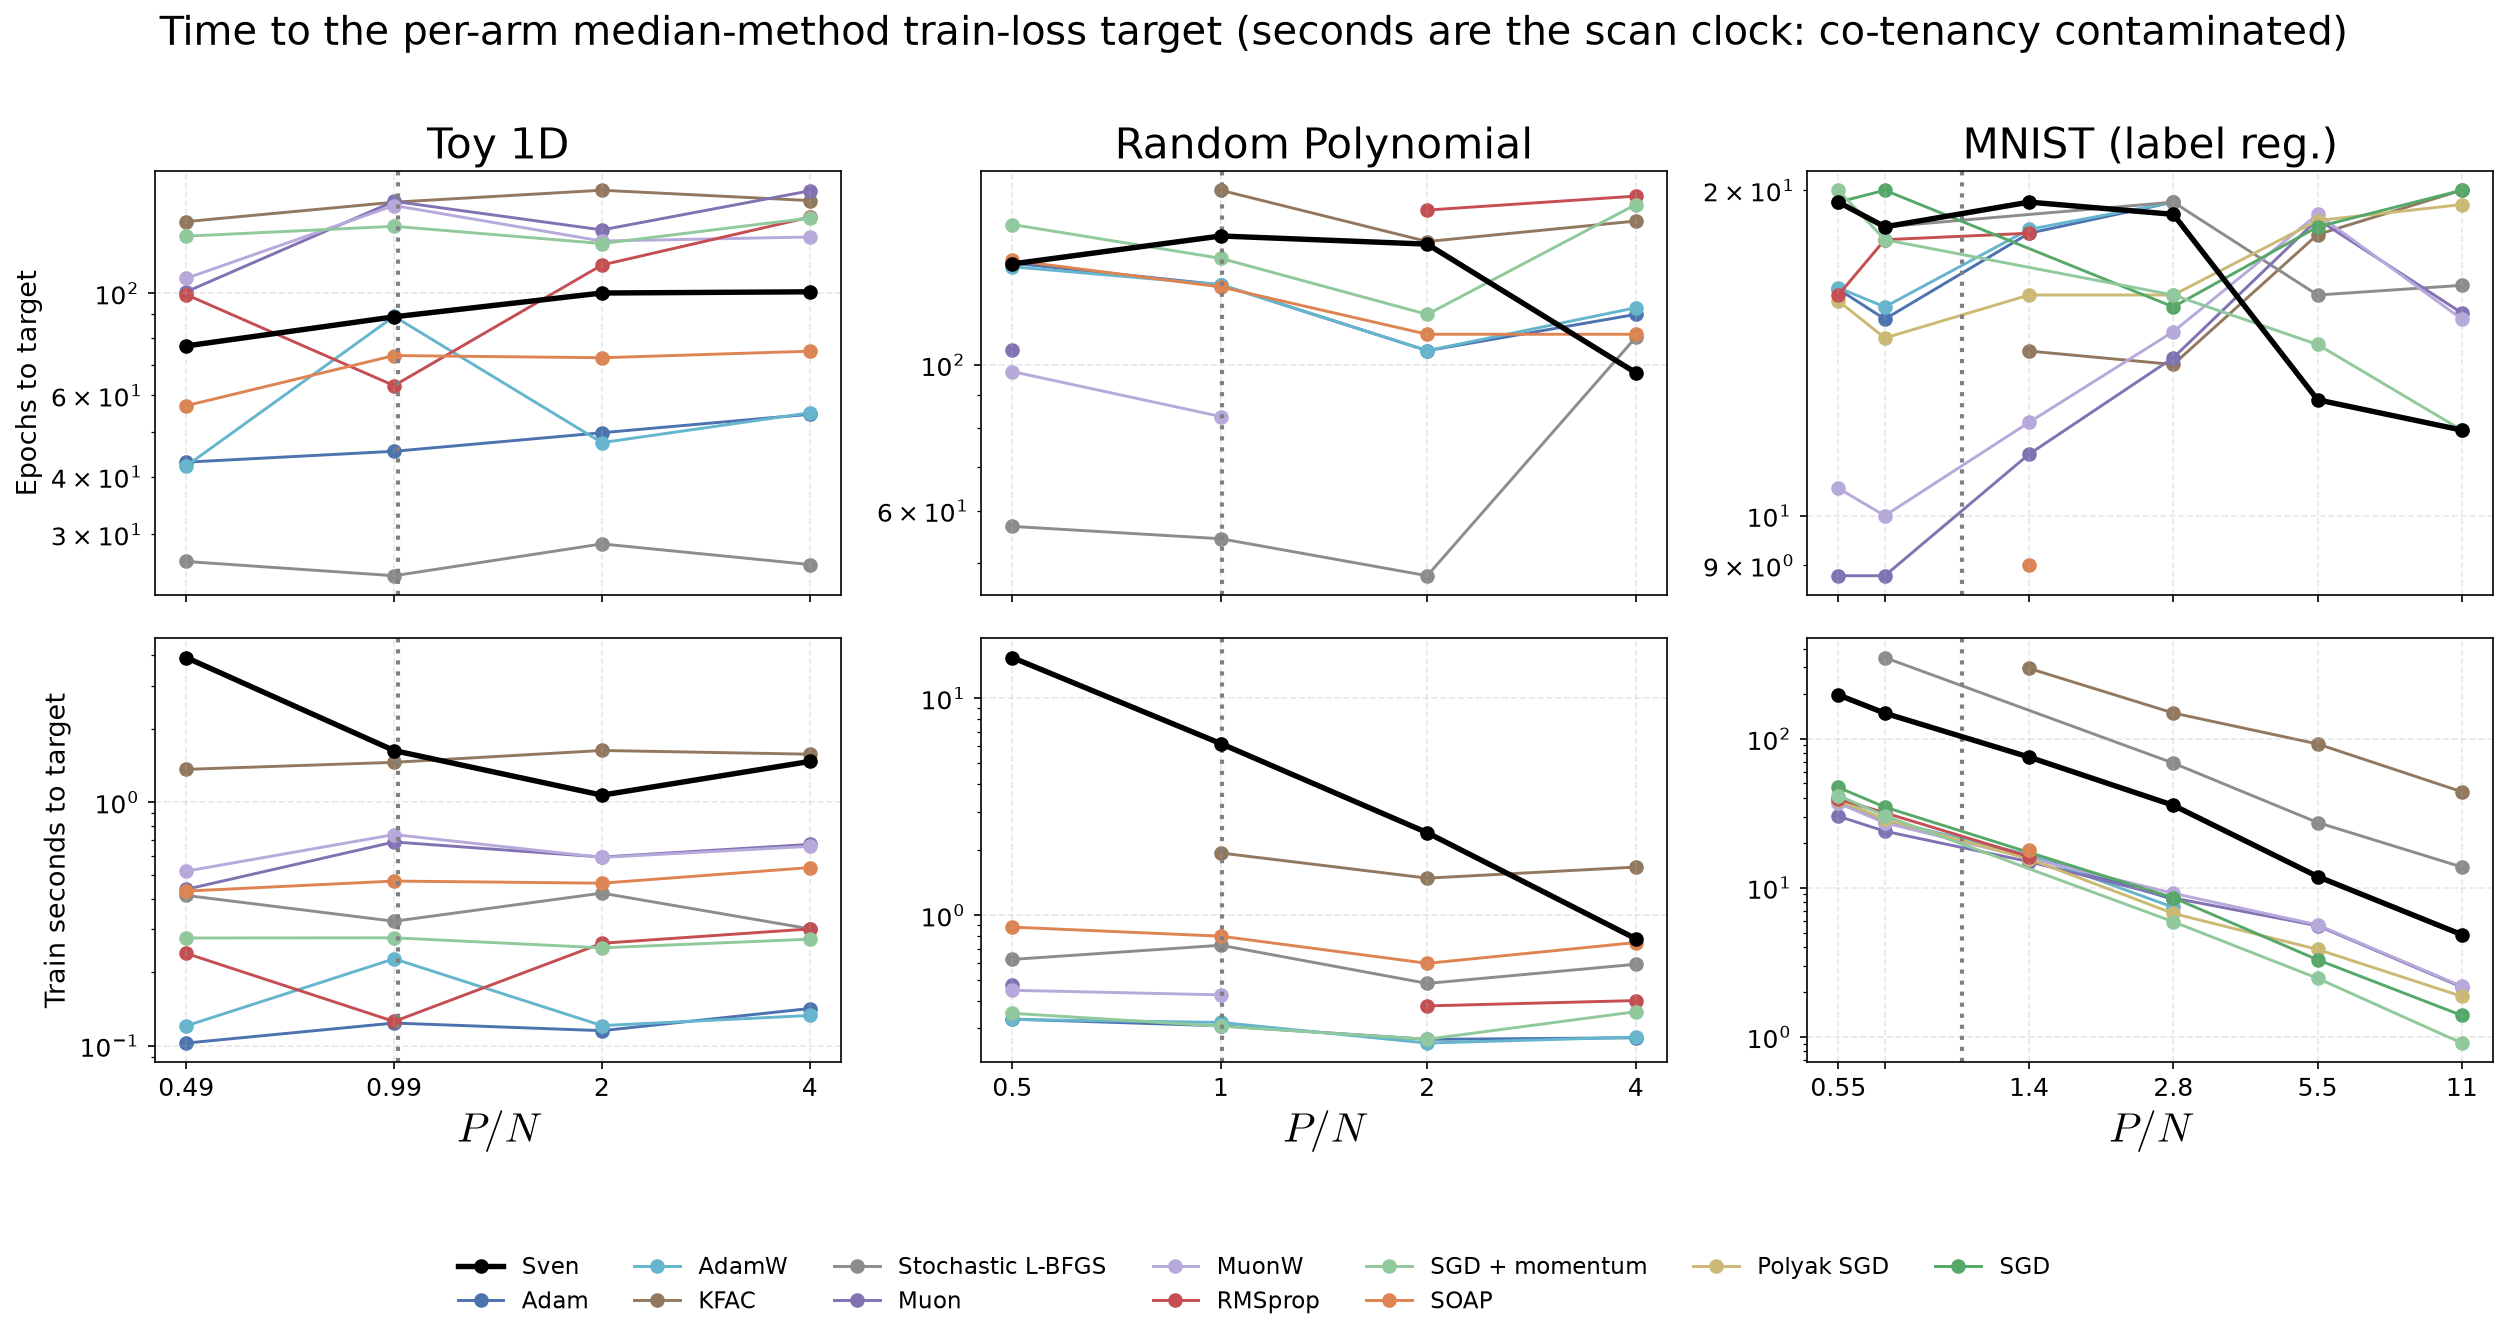

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8.8), sharex='col')
for j, tag in enumerate(best):
    t = reach_rel[tag]
    pn = sorted(P[tag] / n for n in best[tag]['n_data'].unique())
    for i, (q, lab) in enumerate([('epochs', 'Epochs to target'),
                                  ('sync_s', 'Train seconds to target')]):
        ax = axes[i][j]
        for m in method_order(t['method'].unique()):
            s = t[(t['method'] == m) & np.isfinite(t[q])].sort_values('n_data')
            if s.empty:
                continue
            ax.plot([P[tag] / n for n in s['n_data']], s[q], marker='o',
                    lw=2.6 if m == 'Sven' else 1.4, color=method_color(m),
                    label=method_label(m), zorder=3 if m == 'Sven' else 1)
        ax.axvline(1.0, ls=':', c='gray')
        ax.set_xscale('log')
        ax.set_yscale('log')
        rf.arm_ticks(ax, pn, fmt='{:.2g}', min_log_sep=0.12)
        ax.set_xlabel('$P / N$' if i == 1 else '')
        ax.set_ylabel(lab if j == 0 else '', fontsize=13)
        if i == 0:
            ax.set_title(tag)
        ax.grid(alpha=0.3, ls='--')
fig.suptitle('Time to the per-arm median-method train-loss target '
             '(seconds are the scan clock: co-tenancy contaminated)', y=1.0)
rf.figure_legend(fig, axes, ncol=7, fontsize=11, bottom=0.11)
rf.savefig(fig, PLOT_DIR, 'time_to_target_vs_PoverN')
plt.show()

## 5. The legacy claim, re-asked of the fresh runs

> REBUTTALS.md §4.6: *"In the genuine dataset-overparam regime ($P/N > 1$), **Sven is
> consistently 2nd-fastest**, beating every first-order method \[…\] typically ~2–3×
> faster than Adam in wall-time"*, with 1D ranks 2/2/3/5 and polynomial 2/2/2/2 on
> **wall-time to train loss $< 10^{-3}$**.

Three things about that claim have changed underneath it and must be said before any
comparison:

1. the legacy "polynomial" was `AdditiveCubicDataset` — per-variable factors **added**, no
   constant and no linear monomials.  The campaign's `RandomPolynomialDataset` multiplies
   them and is variance-normalised (EXPERIMENTS.md §11): a **different, harder target**, on
   which only a handful of methods reach $10^{-3}$ at all and none does below $P/N = 1$, so
   the legacy ranking cannot be reproduced cell for cell.  The first cell below *counts*
   them per arm rather than asserting a count, so this paragraph and §8 cannot drift apart;
2. the legacy runs generated the validation set from a **shared generator** with train, and
   legacy `AdamW` was configured identically to `Adam`, so its 11-method field contained a
   duplicate;
3. the legacy question itself selects each method's configuration **by how fast it reaches
   the target** — selection on the reported quantity.  It is reproduced below for
   comparison only; the binding-rule answer is §1–§4.

In [13]:
legacy, reached = {}, {}
for tag, df in data.items():
    legacy[tag] = rf.fastest_to_target(df, 'n_data', 1e-3, which='train_eval')
    r = rf.reach_count_table(df, 'n_data', 1e-3, which='train_eval')
    r['P_over_N'] = [P[tag] / n for n in r['n_data']]
    reached[tag] = r

print('HOW MANY methods reach train_eval < 1e-3 on every seed of some configuration, '
      'per arm (the count §5 and §8 both quote):')
for tag, r in reached.items():
    print(f'  == {tag} ==')
    print('    ' + r[['n_data', 'P_over_N', 'n_reached', 'n_field', 'methods']]
          .to_string(index=False, float_format=lambda v: f'{v:.3g}')
          .replace('\n', '\n    '))
over = {tag: r[(r['P_over_N'] > 1)]['n_reached'].sum() for tag, r in reached.items()}
under = {tag: r[(r['P_over_N'] < 1)]['n_reached'].sum() for tag, r in reached.items()}
print(f'\n  reaching 1e-3 anywhere at P/N > 1: {over};  at P/N < 1: {under}')
print()

for tag in best:
    f = legacy[tag]
    print(f'=== {tag}: the FASTEST configuration per method to train_eval < 1e-3 '
          '(legacy-style selection, not the binding rule) ===')
    if f.empty:
        print('    no method reaches 1e-3 on this task at all.\n')
        continue
    for nd in sorted(f['n_data'].unique()):
        s = f[f['n_data'] == nd].sort_values('sync_s').reset_index(drop=True)
        r_s = s.index[s['method'] == 'Sven'].tolist()
        e = s.sort_values('epochs').reset_index(drop=True)
        r_e = e.index[e['method'] == 'Sven'].tolist()
        print(f'  N={nd:5d}  P/N={P[tag]/nd:5.2f}   methods reaching it: {len(s)}'
              f'   Sven rank by seconds: {r_s[0]+1 if r_s else "-"}/{len(s)}'
              f'   by epochs: {r_e[0]+1 if r_e else "-"}/{len(e)}')
        print('    ' + s[['display', 'config', 'epochs', 'sync_s', 'n_reached',
                          'n_runs']].to_string(index=False,
                                               float_format=lambda v: f'{v:.4g}')
              .replace('\n', '\n    '))
    print()

HOW MANY methods reach train_eval < 1e-3 on every seed of some configuration, per arm (the count §5 and §8 both quote):
  == Toy 1D ==
     n_data  P_over_N  n_reached  n_field                                      methods
        150      3.95          5       13 [Adam, AdamW, SOAP, Stochastic L-BFGS, Sven]
        300      1.98          5       13 [Adam, AdamW, SOAP, Stochastic L-BFGS, Sven]
        600     0.988          5       13 [Adam, AdamW, SOAP, Stochastic L-BFGS, Sven]
       1200     0.494          5       13 [Adam, AdamW, SOAP, Stochastic L-BFGS, Sven]
  == Random Polynomial ==
     n_data  P_over_N  n_reached  n_field                         methods
        170      3.96          3       13 [SOAP, Stochastic L-BFGS, Sven]
        340      1.98          1       13                          [Sven]
        675     0.997          0       13                              []
       1350     0.499          0       13                              []
  == MNIST (label reg.) ==
     n_

## 6. Extended learning-rate grids: are the optima still on an edge?

The campaign extended the baseline learning-rate grids (8 values, $10^{-5}$ … 1) and Sven's
rtol grid.  An optimum sitting on the lowest or highest value of the grid it was searched
on means the grid, not the method, may be what is being measured — so it is listed rather
than quietly used.  The grid is taken per (method, arm) from the runs actually present.

In [14]:
edges = []
for tag, b in best.items():
    e = rf.edge_optima(data[tag], b, 'n_data')
    if e.empty:
        continue
    e.insert(0, 'task', tag)
    e['P_over_N'] = [P[tag] / n for n in e['n_data']]
    edges.append(e)
edges = pd.concat(edges, ignore_index=True) if edges else pd.DataFrame()
if edges.empty:
    print('no selected configuration sits on a grid edge.')
else:
    print(edges[['task', 'n_data', 'P_over_N', 'display', 'knob', 'value', 'side',
                 'n_values', 'grid']]
          .to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    print()
    print('per knob:')
    print(edges.groupby(['knob', 'side']).size().rename('n_selected_configs').to_string())

              task  n_data  P_over_N           display knob  value side  n_values          grid
            Toy 1D     150     3.953              Sven    k     37  low         3   [37 .. 150]
            Toy 1D     300     1.977              Sven    k     75  low         3   [75 .. 300]
            Toy 1D     600    0.9883              Sven    k    150  low         3  [150 .. 600]
            Toy 1D    1200    0.4942              Sven    k    300  low         3 [300 .. 1200]
 Random Polynomial     170     3.959              Sven    k    170 high         3   [42 .. 170]
 Random Polynomial     340     1.979              Sven    k    340 high         3   [85 .. 340]
MNIST (label reg.)    2500     11.02              Sven    k     64 high         4    [16 .. 64]
MNIST (label reg.)    5000     5.512              Sven    k     64 high         4    [16 .. 64]
MNIST (label reg.)   50000    0.5512              Sven    k     64 high         4    [16 .. 64]
MNIST (label reg.)    2500     11.02 Sto

## 7. Computed summary

In [15]:
lines = []
lines.append('OVER-PARAMETERISATION SWEEP (P > N) — computed summary')
lines.append('=' * 78)
for tag, b in best.items():
    df = data[tag]
    cen = rf.scan_census(df)
    lines.append(f'{tag}  (P = {P[tag]}, {cen["n_records"]} records, '
                 f'{cen["n_missing"]} missing, {cen["n_diverged"]} diverged wide, '
                 f'{cen["n_methods"]} methods, {len(cen["seeds"])} seeds)')
    sub = sven_rank[sven_rank['task'] == tag].sort_values('P_over_N', ascending=False)
    lines.append('    P/N        : ' + '  '.join(f'{v:7.2f}' for v in sub['P_over_N']))
    lines.append('    Sven rank  : ' + '  '.join(
        f'{int(r):3d}/{int(n):<3d}' for r, n in zip(sub['rank_val'], sub['n_methods'])))
    lines.append('    winner     : ' + '  '.join(f'{w[:9]:>9s}' for w in sub['winner']))
    lines.append('    rank test  : ' + '  '.join(f'{int(r):3d}    ' for r in sub['rank_test']))
    lines.append('    rank train : ' + '  '.join(f'{int(r):3d}    ' for r in sub['rank_train']))
    over = sub[sub['P_over_N'] > 1]
    under = sub[sub['P_over_N'] < 1]
    if len(over) and len(under):
        lines.append(f'    mean rank  : P/N>1 -> {over["rank_val"].mean():.2f},'
                     f'  P/N<1 -> {under["rank_val"].mean():.2f}')
    sv = df[df['method'] == 'Sven']
    lines.append(f'    Sven divergence (wide): {int(sv["diverged"].sum())}/{len(sv)} runs, '
                 f'recorded status=diverged: {int((sv["status"] == "diverged").sum())}')
    ra = reach_abs[tag]
    lines.append('    reaching train_eval < 1e-3 on EVERY seed of the selected config: '
                 f'{sorted(set(ra[ra["all_reached"]]["display"])) or "none"}')
    if not legacy[tag].empty:
        for nd in sorted(legacy[tag]['n_data'].unique()):
            s = legacy[tag][legacy[tag]['n_data'] == nd].sort_values('sync_s') \
                .reset_index(drop=True)
            e = s.sort_values('epochs').reset_index(drop=True)
            rs = s.index[s['method'] == 'Sven'].tolist()
            re_ = e.index[e['method'] == 'Sven'].tolist()
            lines.append(f'    legacy-style N={nd:5d}: Sven '
                         f'{rs[0]+1 if rs else "-"}/{len(s)} by seconds, '
                         f'{re_[0]+1 if re_ else "-"}/{len(e)} by epochs')
    lines.append('')

n_edge_sven = 0 if edges.empty else int((edges['method'] == 'Sven').sum())
lines.append(f'edge optima: {0 if edges.empty else len(edges)} selected configs on a grid '
             f'edge, {n_edge_sven} of them Sven')
for col, name in (('rank_val', 'validation (selected on)'), ('rank_test', 'TEST (outcome)')):
    over_all = sven_rank[sven_rank['P_over_N'] > 1][col].mean()
    under_all = sven_rank[sven_rank['P_over_N'] < 1][col].mean()
    lines.append(f'pooled over the three tasks, {name}: Sven mean rank '
                 f'{over_all:.2f} at P/N > 1 vs {under_all:.2f} at P/N < 1 '
                 f'({len(sven_rank[sven_rank["P_over_N"] > 1])} vs '
                 f'{len(sven_rank[sven_rank["P_over_N"] < 1])} arms)')
wins = int((sven_rank['rank_val'] == 1).sum())
lines.append(f'Sven is 1st on VALIDATION in {wins} of {len(sven_rank)} arms '
             f'({int((sven_rank[sven_rank["P_over_N"] > 1]["rank_val"] == 1).sum())} of '
             f'{len(sven_rank[sven_rank["P_over_N"] > 1])} of them at P/N > 1), and 1st on '
             f'TEST in {int((sven_rank["rank_test"] == 1).sum())} of {len(sven_rank)}')
lines.append(f'of the {n_tot} rank-1/rank-2 gaps, {n_sig} clear(s) the paired seed noise '
             f'at 95% -- every other placement in this sweep is a statistical tie')
for tag, t in dvr.items():
    sv = float(t.loc[t['method'] == 'Sven', 'frac'].iloc[0])
    worse = [m for m in ('SGD', 'SGDm', 'RMSprop')
             if (t['method'] == m).any()
             and float(t.loc[t['method'] == m, 'frac'].iloc[0]) > sv]
    lines.append(f'divergence, {tag}: Sven {100 * sv:.2f}% over '
                 f'{int(t.loc[t["method"] == "Sven", "n_runs"].iloc[0])} runs, '
                 f'{t.attrs["reference_rank"]} of {len(t)} worst-first; of SGD / SGD+mom / '
                 f'RMSprop, worse than Sven: {worse or "none"}')
print('\n'.join(lines))

OVER-PARAMETERISATION SWEEP (P > N) — computed summary
Toy 1D  (P = 593, 3240 records, 0 missing, 202 diverged wide, 13 methods, 5 seeds)
    P/N        :    3.95     1.98     0.99     0.49
    Sven rank  :   2/13     4/13     3/13     3/13 
    winner     : Stochasti  Stochasti  Stochasti  Stochasti
    rank test  :   2        4        3        3    
    rank train :   2        4        3        3    
    mean rank  : P/N>1 -> 3.00,  P/N<1 -> 3.00
    Sven divergence (wide): 111/720 runs, recorded status=diverged: 0
    reaching train_eval < 1e-3 on EVERY seed of the selected config: ['Adam', 'AdamW', 'SOAP', 'Stochastic L-BFGS', 'Sven']
    legacy-style N=  150: Sven 4/5 by seconds, 1/5 by epochs
    legacy-style N=  300: Sven 3/5 by seconds, 1/5 by epochs
    legacy-style N=  600: Sven 4/5 by seconds, 1/5 by epochs
    legacy-style N= 1200: Sven 5/5 by seconds, 1/5 by epochs

Random Polynomial  (P = 673, 4320 records, 0 missing, 369 diverged wide, 13 methods, 5 seeds)
    P/N       

## 8. Conclusion

**Answering R1 plainly: Sven's advantage does depend on $P/N$ — on two of the three tasks —
and it is an advantage per *step*, not per second.**

* **Where the dependence is real — on the selection metric.**  On MNIST label-regression
  Sven is 1st of 13 on **validation** at $P/N = 11.0$, 5.5 and 2.8 and 2nd from $P/N = 1.38$
  down; on the polynomial it is 1st at $P/N = 4.0$, 2nd at 2.0 and 1.0, 4th at 0.5.  Mean
  validation rank over the over-parameterised arms against the under-parameterised ones:
  1.25 vs 2.00 (MNIST), 1.50 vs 3.00 (polynomial), **1.75 vs 2.67** pooled.
* **On the test outcome the same story is weaker, and it has to be quoted too.**  MNIST test
  ranks are **4, 1, 2, 2, 4, 3** across $P/N = 11.0 \to 0.55$ — so the arm the bullet above
  leads with, $P/N = 11$, is a *validation* win and a **4th-of-13 test placement** — and the
  pooled test gap is **2.12 vs 3.17** against validation's 1.75 vs 2.67.  The *trend*
  survives on test; several individual wins do not.  (The polynomial and toy test ranks track
  their validation ranks closely: 1/1/2/4 and 2/4/3/3.)
* **Almost none of the individual placements clears the seed spread.**  Paired by the 5 model
  seeds — same initialisation, same data order, so the pairing removes exactly the variance
  the error bars show — **1 of the 14 rank-1/rank-2 gaps is significant at 95%**, and it is
  the toy arm where Sven is 2nd (Sven − Adam $= -9.3\times10^{-5}$, $t = -2.84$; the gap to
  L-BFGS *above* it is not significant).  Every arm the conclusion leads with is a tie:
  MNIST $N = 2500$ Sven − PolyakSGD $= -3.3\times10^{-4}$ ($t = -0.13$), − SGD $t = -0.44$;
  $N = 5000$ − SGD $t = -0.83$, − L-BFGS $t = -1.00$; $N = 10{,}000$ − SGD $t = -0.99$,
  − MuonW $t = -0.70$; polynomial $N = 170$ − SGD+momentum $t = -0.40$, − MuonW $t = -0.58$.
  The *losses*, by contrast, are real: MNIST $N = 40{,}000$ Sven − MuonW $= +4.1\times10^{-3}$
  ($t = +4.39$) and polynomial $N = 675$ Sven − L-BFGS $= +0.072$ ($t = +11.08$) both clear
  95% against Sven.  So "1st of 13 at $P/N = 11.0$, 5.5 and 2.8" means "at the top of a
  statistical tie of three to four methods": the result is the *trend* in rank across $P/N$,
  not any single arm.
* **Where it is not.**  On the toy 1-D task Sven ranks 2 / 4 / 3 / 3 across
  $P/N = 3.95 / 1.98 / 0.99 / 0.49$ — mean rank 3.00 on both sides of the boundary, i.e.
  **no** $P/N$ dependence, and Stochastic L-BFGS wins every arm.  The claim has to be made
  on the two tasks that support it, not on all three.
* **It is not a wall-clock advantage.**  Under the legacy question (each method's *fastest*
  configuration to `train_eval` $< 10^{-3}$) Sven reaches the target in the fewest epochs in
  every toy arm — 23.6–27.4 against L-BFGS 28.4–43 and Adam 57–64 — and ranks 3rd–5th of the
  5 methods that get there at all once the epochs are priced in seconds.  So the legacy
  "**consistently 2nd-fastest for $P/N > 1$**" does not reproduce, and neither does its
  crossover (fresh ranks by seconds are 4 / 3 / 4 / 5, flat across the boundary).  The
  legacy polynomial row — 2nd at every $P/N$, train loss down to $10^{-8}$–$10^{-11}$ —
  cannot be reproduced on the corrected target: only 3 of 13 methods reach
  $10^{-3}$ at $P/N = 4.0$ (Sven fastest at 95.6 epochs / 0.751 s, then SOAP 151.4 / 0.874
  and L-BFGS 135.4 / 1.413), only Sven reaches it at $P/N = 2.0$, and **nobody** reaches it
  in the two under-parameterised arms.  On MNIST *no* method reaches $10^{-3}$ in any arm.
* **Optimising is not fitting.**  Sven's rank on the full-training-set loss is much worse
  than its rank on validation wherever the two disagree (MNIST $N = 10{,}000$: 1st on
  validation, 10th on `train_eval`), and on MNIST *no* method gets the training loss below
  $10^{-3}$ even at $P/N = 11$.  "Over-parameterised" here means $P > N$ in the counting
  sense, not "interpolates".
* **Robustness, stated honestly — and Sven is not uniformly the safer method.**  Sven never
  records `status: diverged` on these scans, yet the wide rule counts 111 / 720 = 15.42%
  (toy) and 252 / 1800 = 14.00% (polynomial) blow-ups against 1 / 360 = 0.28% on MNIST,
  concentrated at the bottom of the `rtol` grid — the pattern of EXPERIMENTS.md §7.  A reader
  who looked only at the status field would conclude Sven never fails.  Per scan (§3):
  * **polynomial — Sven is worse than SGD and SGD+momentum.**  14.00% against SGD's
    12.50% (20/160) and SGD+momentum's 11.25% (18/160); only RMSprop (30.62%) is worse, so
    Sven is **2nd worst of the 13 methods** there.
  * **toy** — 15.42% just below SGD's 15.62% and clearly below SGD+momentum's 20.00% and
    RMSprop's 20.62%; Sven is 4th worst of 13.
  * **MNIST** — 0.28%, second *best* of 13, far below K-FAC's 52.92% and L-BFGS's 27.78%.

  And these rates are not measured over comparable grids: Sven's is **11.25× larger** on the
  two synthetic tasks (1,800 vs 160 runs) because it spans an `rtol` axis the baselines do
  not have, and that axis deliberately includes values known to break.  Pooling the three
  scans, or comparing 1,800 runs with 160, would be the kind of reassurance this section
  exists to avoid.
* **Edge optima are listed, not hidden.**  11 of the 14 edge cases are Sven's, and the
  `rank_eff` column explains most of them: with `rtol` $= 10^{-3}$ on the toy task only
  ~12 singular directions survive the cut whatever $k$ allows, so $k$ is free to sit on
  either end of its grid without changing the update.  Five of the eleven are $k$ at the top
  of its list, which on MNIST means $k = 64 = B$ — a **natural maximum, not a grid edge**
  (ANALYSIS_PLAN §0), so nothing there is extendable.  The one that is: Sven selects
  $\eta = 1$, the top of the learning-rate list, at MNIST $N = 2500$ and $N = 5000$ — the
  two arms it wins on validation.  That is the grid to extend if the sweep is ever rerun,
  and it is the same shape of open edge as the CIFAR-CE `rtol` extension.